In [25]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU NOT AVAILABLE")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [26]:
from google.colab import files

uploaded = files.upload()

Saving test_shapes.py to test_shapes (2).py
Saving train.py to train (2).py
Saving uie_model.py to uie_model (1).py


In [27]:
!ls -lh


total 116K
drwx------ 5 root root 4.0K Aug 17 14:58  drive
-rw-r--r-- 1 root root 4.2K Aug 17 15:16  evaluate.py
-rw-r--r-- 1 root root 1.7K Aug 17 14:57  generate_dummy_data.py
-rw-r--r-- 1 root root 1.8K Aug 17 15:14  inference.py
drwxr-xr-x 2 root root 4.0K Aug 17 15:05  __pycache__
drwxr-xr-x 1 root root 4.0K Aug 10 13:31  sample_data
-rw-r--r-- 1 root root 2.8K Aug 17 14:57 'test_shapes (1).py'
-rw-r--r-- 1 root root 2.8K Aug 17 15:22 'test_shapes (2).py'
-rw-r--r-- 1 root root 2.8K Aug 17 14:57  test_shapes.py
-rw-r--r-- 1 root root  11K Aug 17 14:57 'train (1).py'
-rw-r--r-- 1 root root  11K Aug 17 15:22 'train (2).py'
-rw-r--r-- 1 root root  11K Aug 17 14:57  train.py
-rw-r--r-- 1 root root  18K Aug 17 15:22 'uie_model (1).py'
-rw-r--r-- 1 root root  18K Aug 17 14:57  uie_model.py


In [28]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!find /content/drive/MyDrive -maxdepth 3 -type d -name "dataset"

/content/drive/MyDrive/Dataset/dataset
/content/drive/MyDrive/dataset


In [30]:
!ls -lah /content/drive/MyDrive/Dataset/dataset

total 8.0K
drwx------ 2 root root 4.0K Aug 17 14:14 raw
drwx------ 2 root root 4.0K Aug 17 14:15 ref


In [31]:
!find /content/drive/MyDrive/Dataset/dataset/raw -type f | head -10

/content/drive/MyDrive/Dataset/dataset/raw/Copy of 866.png
/content/drive/MyDrive/Dataset/dataset/raw/Copy of 616.png
/content/drive/MyDrive/Dataset/dataset/raw/Copy of 880.png


In [32]:
!find /content/drive/MyDrive/Dataset/dataset/ref -type f | head -10

/content/drive/MyDrive/Dataset/dataset/ref/Copy of 866.png
/content/drive/MyDrive/Dataset/dataset/ref/Copy of 616.png
/content/drive/MyDrive/Dataset/dataset/ref/Copy of 880.png


In [33]:
from pathlib import Path

raw = Path("/content/drive/MyDrive/Dataset/dataset/raw")
ref = Path("/content/drive/MyDrive/Dataset/dataset/ref")

raw_files = {p.name for p in raw.iterdir() if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]}
ref_files = {p.name for p in ref.iterdir() if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]}

print("Raw images:", len(raw_files))
print("Reference images:", len(ref_files))
print("Matching pairs:", len(raw_files & ref_files))

Raw images: 3
Reference images: 3
Matching pairs: 3


In [34]:
!python test_shapes.py

Device: cuda
UIENet parameters: 6,038,223

--- Shape check ---
input            : (2, 3, 256, 256)
output           : (2, 3, 256, 256)
view[0]          : (2, 3, 256, 256)
view[1]          : (2, 3, 256, 256)
view[2]          : (2, 3, 256, 256)
view[3]          : (2, 3, 256, 256)
fusion gates     : (2, 4, 64, 256, 256)  (B, n_views, C, H, W)
fused features   : (2, 64, 256, 256)
residual delta   : (2, 3, 256, 256)

[OK] output shape matches input, range in [0,1], fusion gates sum to 1 across views.
Traceback (most recent call last):
  File "/content/test_shapes.py", line 73, in <module>
    main()
  File "/content/test_shapes.py", line 46, in main
    out2 = model(x_grad)
           ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1790, in _call_im

In [35]:
!python train.py \
    --data_dir /content/drive/MyDrive/Dataset/dataset \
    --epochs 2 \
    --batch_size 1 \
    --crop_size 256 \
    --num_workers 2 \
    --ckpt_dir /content/drive/MyDrive/Dataset/checkpoints \
    --save_every 1 \
    --log_every 1

Using device: cuda
Training pairs: 3
Traceback (most recent call last):
  File "/content/train.py", line 256, in <module>
    train(parse_args())
  File "/content/train.py", line 170, in train
    out = model(raw)
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1790, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/uie_model.py", line 342, in forward
    refined = self.refine(fused)                     # (B,nf,H,W)
              ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1779, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12

In [36]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.get_device_name(0))
print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Tesla T4
Allocated: 0.00 GB


In [37]:
!python train.py \
    --data_dir /content/drive/MyDrive/Dataset/dataset \
    --epochs 2 \
    --batch_size 1 \
    --crop_size 128 \
    --num_workers 0 \
    --ckpt_dir /content/drive/MyDrive/Dataset/checkpoints \
    --save_every 1 \
    --log_every 1

Using device: cuda
Training pairs: 3
epoch 000 step 000000 | pix 0.0321 perc 0.8870 g_gan 0.0000 d 0.0000
epoch 000 step 000001 | pix 0.0770 perc 1.1286 g_gan 0.0000 d 0.0000
epoch 000 step 000002 | pix 0.1027 perc 0.4992 g_gan 0.0000 d 0.0000
Saved checkpoint at epoch 1
epoch 001 step 000003 | pix 0.1513 perc 0.8488 g_gan 0.0000 d 0.0000
epoch 001 step 000004 | pix 0.1015 perc 0.9818 g_gan 0.0000 d 0.0000
epoch 001 step 000005 | pix 0.1280 perc 0.9123 g_gan 0.0000 d 0.0000
Saved checkpoint at epoch 2
Training complete.


In [38]:
!python train.py \
    --data_dir /content/drive/MyDrive/Dataset/dataset \
    --epochs 100 \
    --batch_size 1 \
    --crop_size 128 \
    --num_workers 0 \
    --ckpt_dir /content/drive/MyDrive/Dataset/checkpoints_100 \
    --save_every 10 \
    --log_every 3

Using device: cuda
Training pairs: 3
epoch 000 step 000000 | pix 0.1293 perc 1.2958 g_gan 0.0000 d 0.0000
epoch 001 step 000003 | pix 0.1012 perc 0.9999 g_gan 0.0000 d 0.0000
epoch 002 step 000006 | pix 0.0864 perc 1.1655 g_gan 0.0000 d 0.0000
epoch 003 step 000009 | pix 0.0632 perc 0.6682 g_gan 0.0000 d 0.0000
epoch 004 step 000012 | pix 0.1271 perc 1.2208 g_gan 0.0000 d 0.0000
epoch 005 step 000015 | pix 0.1471 perc 1.1433 g_gan 0.0000 d 0.0000
epoch 006 step 000018 | pix 0.0905 perc 0.9144 g_gan 0.0000 d 0.0000
epoch 007 step 000021 | pix 0.0504 perc 0.8324 g_gan 0.0000 d 0.0000
epoch 008 step 000024 | pix 0.1029 perc 0.9491 g_gan 0.0000 d 0.0000
epoch 009 step 000027 | pix 0.1128 perc 0.8949 g_gan 0.0000 d 0.0000
Saved checkpoint at epoch 10
epoch 010 step 000030 | pix 0.0749 perc 0.6332 g_gan 0.0000 d 0.0000
epoch 011 step 000033 | pix 0.0675 perc 0.7274 g_gan 0.0000 d 0.0000
epoch 012 step 000036 | pix 0.0381 perc 0.8363 g_gan 0.0000 d 0.0000
epoch 013 step 000039 | pix 0.1453 pe

In [39]:
%%writefile inference.py
import argparse
from pathlib import Path

import torch
from PIL import Image
from torchvision import transforms

from uie_model import UIENet


def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transforms.ToTensor()(img).unsqueeze(0)
    return img, tensor


def save_image(tensor, path):
    tensor = tensor.squeeze(0).clamp(0, 1).cpu()
    img = transforms.ToPILImage()(tensor)
    img.save(path)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--ckpt", required=True)
    parser.add_argument("--input_dir", required=True)
    parser.add_argument("--output_dir", required=True)
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = UIENet().to(device)

    checkpoint = torch.load(args.ckpt, map_location=device)

    if "model" in checkpoint:
        model.load_state_dict(checkpoint["model"])
    elif "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.eval()

    input_dir = Path(args.input_dir)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    files = sorted([
        p for p in input_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])

    print("Input images:", len(files))

    with torch.no_grad():
        for path in files:
            original, tensor = load_image(path)
            tensor = tensor.to(device)

            output = model(tensor)

            out_path = output_dir / path.name
            save_image(output, out_path)

            print(f"Saved: {out_path}")

    print("Inference complete.")


if __name__ == "__main__":
    main()

Overwriting inference.py


In [40]:
!python inference.py \
    --ckpt /content/drive/MyDrive/Dataset/checkpoints_100/uienet_epoch100.pt \
    --input_dir /content/drive/MyDrive/Dataset/dataset/raw \
    --output_dir /content/drive/MyDrive/Dataset/enhanced

Using device: cuda
Input images: 3
Saved: /content/drive/MyDrive/Dataset/enhanced/Copy of 616.png
Saved: /content/drive/MyDrive/Dataset/enhanced/Copy of 866.png
Saved: /content/drive/MyDrive/Dataset/enhanced/Copy of 880.png
Inference complete.


In [41]:
!ls -lah /content/drive/MyDrive/Dataset/enhanced

total 2.7M
-rw------- 1 root root 1.1M Aug 17 15:26 'Copy of 616.png'
-rw------- 1 root root 894K Aug 17 15:26 'Copy of 866.png'
-rw------- 1 root root 732K Aug 17 15:27 'Copy of 880.png'


In [42]:
!pip install -q scikit-image opencv-python

In [43]:
%%writefile evaluate.py

from pathlib import Path
import cv2
import numpy as np

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity


RAW_DIR = Path("/content/drive/MyDrive/Dataset/dataset/raw")
REF_DIR = Path("/content/drive/MyDrive/Dataset/dataset/ref")
ENH_DIR = Path("/content/drive/MyDrive/Dataset/enhanced")


def load_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not read: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    return img


def calculate_psnr(enhanced, reference):
    return peak_signal_noise_ratio(
        reference,
        enhanced,
        data_range=1.0
    )


def calculate_ssim(enhanced, reference):
    return structural_similarity(
        reference,
        enhanced,
        channel_axis=2,
        data_range=1.0
    )


def calculate_uiqm(img):
    """
    Simplified UIQM implementation:
    UIQM = 0.0282*UICM + 0.2953*UISM + 3.5753*UIConM
    """

    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)

    # ---------- UICM ----------
    rg = img[:, :, 0].astype(np.float32) - img[:, :, 1].astype(np.float32)
    yb = (
        0.5 * (img[:, :, 0].astype(np.float32) +
               img[:, :, 1].astype(np.float32))
        - img[:, :, 2].astype(np.float32)
    )

    uicm = np.std(rg) + np.std(yb)

    # ---------- UISM ----------
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobel = cv2.Sobel(gray, cv2.CV_32F, 1, 1)
    uism = np.mean(np.abs(sobel))

    # ---------- UIConM ----------
    contrast = np.std(gray.astype(np.float32))

    uiqm = (
        0.0282 * uicm +
        0.2953 * uism +
        3.5753 * contrast
    )

    return float(uiqm)


def calculate_uciqe(img):
    """
    UCIQE:
    UCIQE = c1*σc + c2*con_l + c3*μs
    """

    img8 = np.clip(img * 255.0, 0, 255).astype(np.uint8)

    hsv = cv2.cvtColor(img8, cv2.COLOR_RGB2HSV).astype(np.float32)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1] / 255.0
    V = hsv[:, :, 2] / 255.0

    sigma_c = np.std(S)

    con_l = np.percentile(V, 99) - np.percentile(V, 1)

    mu_s = np.mean(S)

    c1 = 0.4680
    c2 = 0.2745
    c3 = 0.2576

    uciqe = (
        c1 * sigma_c +
        c2 * con_l +
        c3 * mu_s
    )

    return float(uciqe)


def main():

    raw_files = sorted([
        p for p in RAW_DIR.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]
    ])

    results = []

    for raw_path in raw_files:

        name = raw_path.name

        ref_path = REF_DIR / name
        enh_path = ENH_DIR / name

        if not ref_path.exists():
            print(f"Reference missing: {name}")
            continue

        if not enh_path.exists():
            print(f"Enhanced missing: {name}")
            continue

        raw = load_image(raw_path)
        enhanced = load_image(enh_path)
        reference = load_image(ref_path)

        # Make sure dimensions match
        if enhanced.shape != reference.shape:
            enhanced = cv2.resize(
                enhanced,
                (reference.shape[1], reference.shape[0])
            )

        psnr = calculate_psnr(enhanced, reference)
        ssim = calculate_ssim(enhanced, reference)
        uiqm = calculate_uiqm(enhanced)
        uciqe = calculate_uciqe(enhanced)

        results.append({
            "image": name,
            "PSNR": psnr,
            "SSIM": ssim,
            "UIQM": uiqm,
            "UCIQE": uciqe
        })

        print(f"\n{name}")
        print(f"PSNR  : {psnr:.4f}")
        print(f"SSIM  : {ssim:.4f}")
        print(f"UIQM  : {uiqm:.4f}")
        print(f"UCIQE : {uciqe:.4f}")

    if results:

        print("\n" + "=" * 60)
        print("AVERAGE RESULTS")
        print("=" * 60)

        print(
            f"Average PSNR  : "
            f"{np.mean([r['PSNR'] for r in results]):.4f}"
        )

        print(
            f"Average SSIM  : "
            f"{np.mean([r['SSIM'] for r in results]):.4f}"
        )

        print(
            f"Average UIQM  : "
            f"{np.mean([r['UIQM'] for r in results]):.4f}"
        )

        print(
            f"Average UCIQE : "
            f"{np.mean([r['UCIQE'] for r in results]):.4f}"
        )


if __name__ == "__main__":
    main()

Overwriting evaluate.py


In [44]:
!python evaluate.py


Copy of 616.png
PSNR  : 19.2571
SSIM  : 0.8278
UIQM  : 179.2369
UCIQE : 0.5442

Copy of 866.png
PSNR  : 16.2961
SSIM  : 0.6713
UIQM  : 245.1072
UCIQE : 0.4846

Copy of 880.png
PSNR  : 24.1426
SSIM  : 0.9260
UIQM  : 137.7715
UCIQE : 0.3817

AVERAGE RESULTS
Average PSNR  : 19.8986
Average SSIM  : 0.8084
Average UIQM  : 187.3719
Average UCIQE : 0.4702


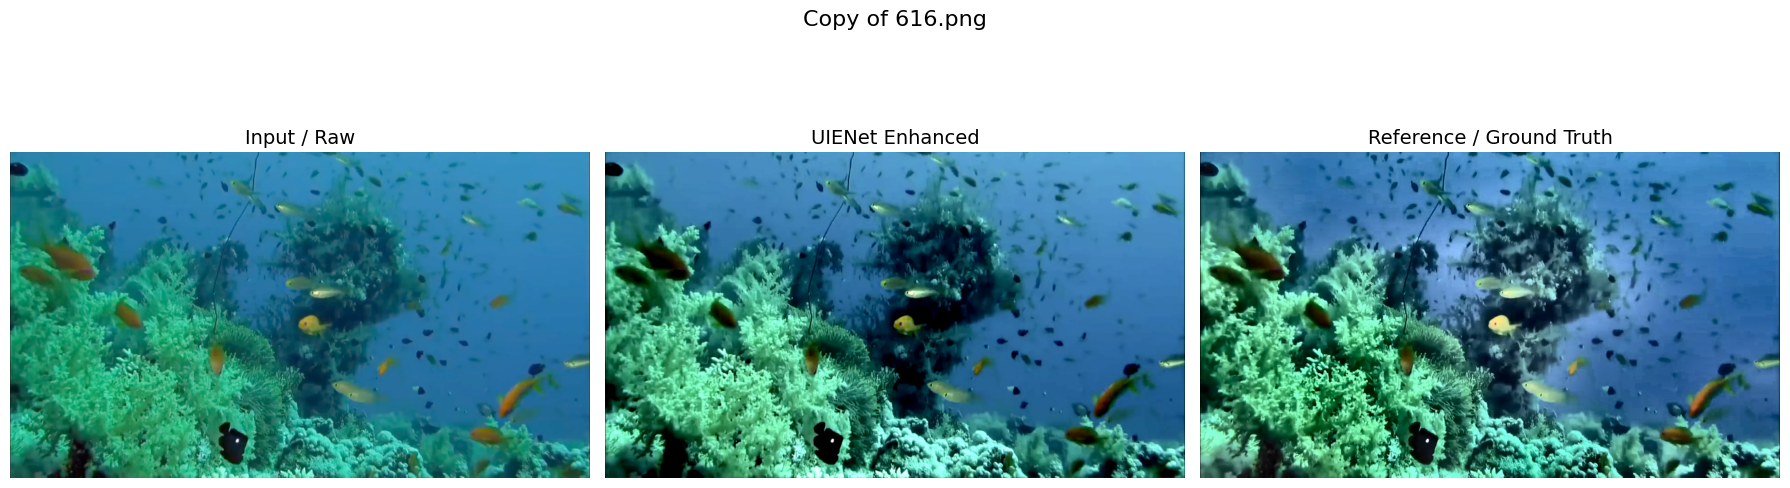

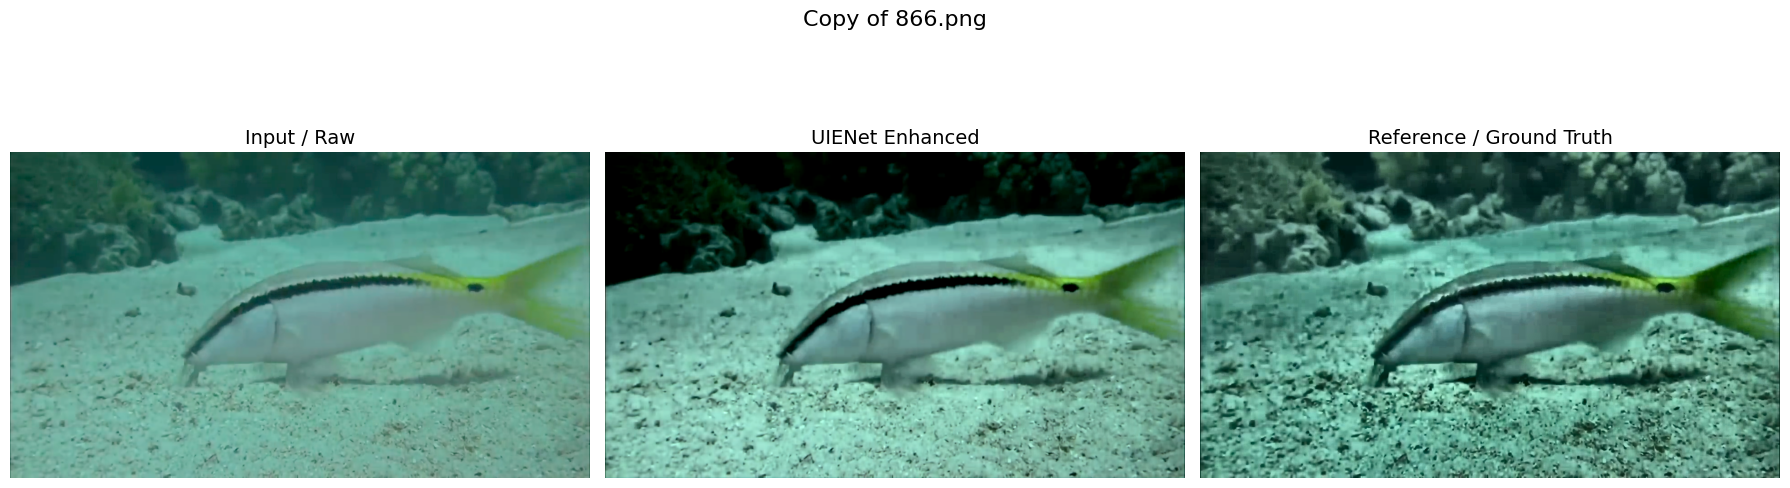

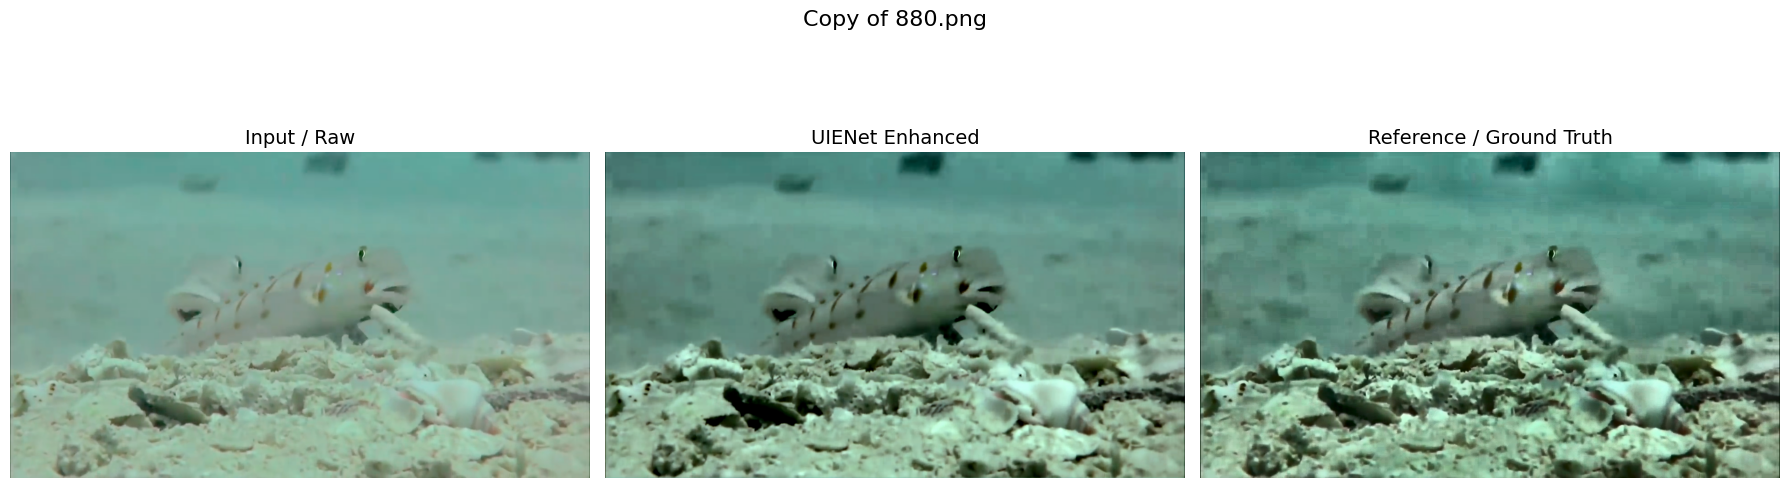

In [45]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

raw_dir = Path("/content/drive/MyDrive/Dataset/dataset/raw")
enh_dir = Path("/content/drive/MyDrive/Dataset/enhanced")
ref_dir = Path("/content/drive/MyDrive/Dataset/dataset/ref")

files = sorted([
    p for p in raw_dir.iterdir()
    if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]
])

for file in files:
    name = file.name

    raw_path = raw_dir / name
    enh_path = enh_dir / name
    ref_path = ref_dir / name

    raw = Image.open(raw_path).convert("RGB")
    enhanced = Image.open(enh_path).convert("RGB")
    reference = Image.open(ref_path).convert("RGB")

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(raw)
    plt.title("Input / Raw", fontsize=14)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(enhanced)
    plt.title("UIENet Enhanced", fontsize=14)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(reference)
    plt.title("Reference / Ground Truth", fontsize=14)
    plt.axis("off")

    plt.suptitle(name, fontsize=16)
    plt.tight_layout()
    plt.show()